In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [3]:
#define state
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [4]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight']
    height = state['height']

    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

In [5]:
def label_bmi_category(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'

    return state

In [6]:
#define the state graph
graph = StateGraph(BMIState)

# add nodes to the graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi_category', label_bmi_category)

#add edges to the graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi_category')
graph.add_edge('label_bmi_category', END)

#compile the graph
workflow = graph.compile()

In [8]:
#execute the graph with initial state
initial_state = {'weight': 70, 'height': 1.75}

final_state = workflow.invoke(initial_state)
print(final_state)  # Output: {'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


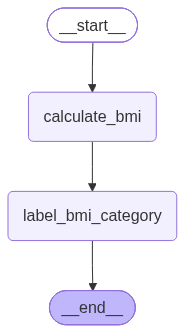

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())